# Generate null brain maps for significance testing

This tutorial demonstrates how to use the eigenstrapping framework, developed by [Koussis *et al.* (2025)](https://doi.org/10.1162/IMAG.a.71), to generate null distributions for statistical analysis of associations between brain annotations. 

A null map, $y'(\vec{r})$, is generated according to the following equation:

$$y'(\vec{r})=\sum\limits_{\Lambda=0}^G\sum\limits_{\mu=-\Lambda}^\Lambda\bigg(\beta_{\Lambda\mu}\psi'_{\Lambda\mu}(\vec{r})\bigg)+\epsilon(\vec{r})$$

where:
- $\Lambda$ denotes the eigengroup
- $\mu$ denotes the eigenmode within the eigengroup
- $G$ is the maximum eigengroup
- $\beta_{\Lambda\mu}$ are the coefficients obtained by decomposing the original map onto the eigenmodes
- $\psi'_{\Lambda\mu}(\vec{r})$ are the new eigenmodes from the rotated eigengroup
- $\epsilon(\vec{r})$ is the residual term

In [1]:
from importlib.resources import as_file, files

import matplotlib.pyplot as plt
import numpy as np
from nsbutils.plotting import plot_surf

from neuromodes.eigen import EigenSolver, get_eigengroup_inds
from neuromodes.io import fetch_example_map, fetch_example_surf
from neuromodes.mesh import unmask_data


In [2]:
# Configuration
res = "32k"
n_modes = 15**2   # First 15 eigengroups
n_nulls = 1000
seed = 0

We start by loading a mesh, initiating the `EigenSolver` class, and computing the eigenmodes.

In [3]:
hemi = 'L'
structure = 'midthickness'
mesh, medmask = fetch_example_surf(structure=structure, res=res, hemi='L')
myelinmap = fetch_example_map('myelinmap', res=res)[medmask]

solver = EigenSolver(mesh, mask=medmask).solve(n_modes)

We can then call the `eigenstrap` class method to generate a null distribution. We will use `resample="exact"` to exactly match the sorted distribution of the original data.

In [4]:
# Calculate nulls
nulls = solver.eigenstrap(
    data=myelinmap,
    n_nulls=n_nulls,
    seed=seed,
    resample="exact"
)
print(nulls.shape)

(29696, 1000)


Now let's visualize the original map and a few null maps.

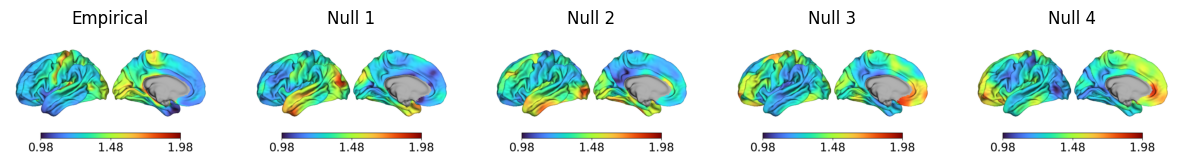

In [5]:
# Plot nulls
lh_surfpath = files('neuromodes.data') / f'sp-human_tpl-fsLR_den-{res}_hemi-{hemi}_{structure}.surf.gii'

with as_file(lh_surfpath) as lh_surfpath:
    fig1, axs = plt.subplots(1, 5, figsize=(15, 6))
    axs = axs.ravel()
    for i, ax_i in enumerate(axs):
        if i == 0:
            data = unmask_data(myelinmap, medmask)
            title = "Empirical"
        else:
            data = unmask_data(nulls[:, i-1], medmask)
            title = f"Null {i}"

        plot_surf(lh_surfpath, data, cmap="turbo", ax=ax_i, cbar=True)
        ax_i.set_title(title)

We can check that the power spectrum distribution between the original and the nulls is approximately preserved on the cortex (it will be exactly preserved only on surfaces where the group relationship is exact, i.e. the sphere). 

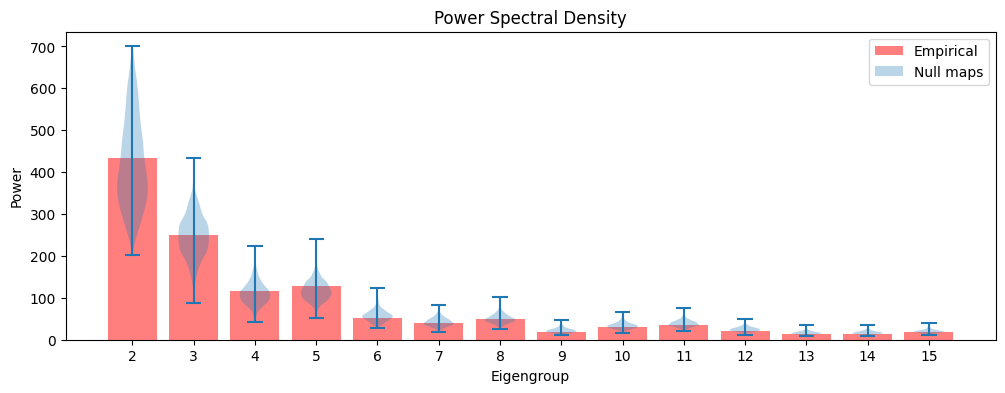

In [6]:
groups = get_eigengroup_inds(n_modes)
n_groups = len(groups)
group_indices = np.concatenate([np.full(len(group), i) for i, group in enumerate(groups)])

beta0 = solver.decompose(myelinmap)
psd0 = np.bincount(group_indices, weights=beta0.ravel()**2)

beta1 = solver.decompose(nulls)
psd1 = np.array([np.bincount(group_indices, weights=beta1[:, i].ravel()**2) for i in range(n_nulls)])

fig, axs = plt.subplots(figsize=(12,4))
axs.bar(range(2,n_groups+1), psd0[1:], color="red", alpha=0.5)
violin_parts = axs.violinplot(psd1[:,1:], positions=range(2,n_groups+1))
axs.legend([axs.patches[0], violin_parts['bodies'][0]], ['Empirical', 'Null maps'])
axs.set_title("Power Spectral Density")
axs.set_xlabel("Eigengroup")
axs.set_xticks(range(2,n_groups+1))
axs.set_ylabel("Power")
plt.show()

Let's also plot the distribution of correlation coefficients between every pair of null maps.

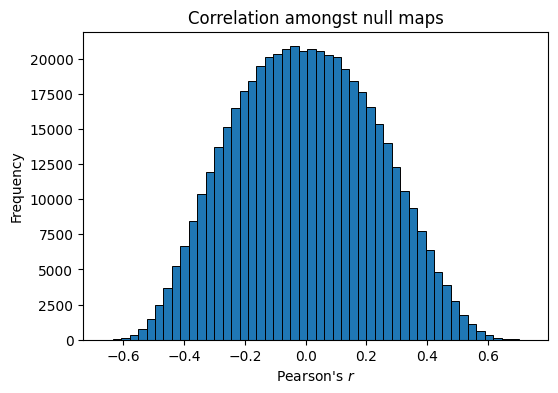

In [7]:
# Plot null correlation distribution
inter_null_corrs = np.corrcoef(nulls.T)
triu_inds = np.triu_indices_from(inter_null_corrs, k=1)
fig2, ax2 = plt.subplots(figsize=(6, 4))
ax2.hist(inter_null_corrs[triu_inds], bins=50, edgecolor='black', linewidth=0.7)
ax2.set_title("Correlation amongst null maps")
ax2.set_xlabel("Pearson's $r$")
ax2.set_ylabel("Frequency")

plt.show()

Now we can use our nulls to test whether the myelinmap is significantly correlated with the principal gradient of functional connectivity ([Margulies *et al.* (2016)](https://doi.org/10.1073/pnas.1608282113)).

Observed correlation between myelinmap and fcgradient1: -0.5262
p-value: 0.0010


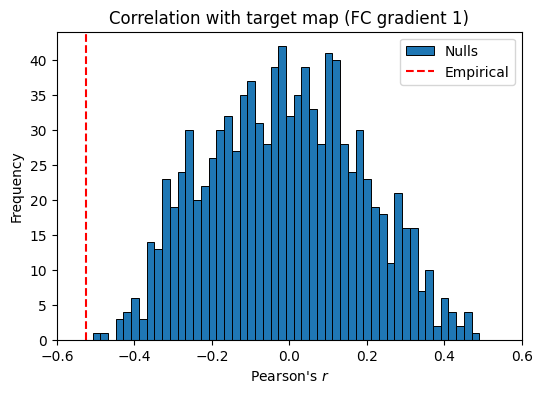

In [8]:
fcgrad = fetch_example_map("fcgradient1", res=res)[medmask]

# Compute correlation between myelinmap and fcgradient1
corr = np.corrcoef(myelinmap, fcgrad)[0, 1]

# Compute correlation between myelinmap and nulls
null_corrs = np.corrcoef(myelinmap, nulls, rowvar=False)[0, 1:]

pvalue = (np.sum(np.abs(null_corrs) >= np.abs(corr)) + 1) / (n_nulls + 1)
print(f"Observed correlation between myelinmap and fcgradient1: {corr:.4f}")
print(f"p-value: {pvalue:.4f}")

# Plot correlation distributions
fig, ax_i = plt.subplots(figsize=(6, 4))
ax_i.hist(null_corrs, bins=50, edgecolor="black", linewidth=0.7, label="Nulls")
ax_i.axvline(corr, color="red", linestyle="--", label="Empirical")
ax_i.set_title("Correlation with target map (FC gradient 1)")
ax_i.set_xlabel("Pearson's $r$")
ax_i.set_ylabel("Frequency")
ax_i.set_xlim(-0.6, 0.6)
ax_i.legend()
plt.show()